# Sentinelle 237 — Entraînement du classifieur d'articles

Ce notebook remplace `ml/train_and_export.py` en version interactive : chargement des données
**directement depuis la base Postgres de production/sandbox** (pas de fichier externe), exploration,
entraînement TF-IDF + Régression Logistique, évaluation, puis export ONNX + vectoriseur JSON pour
le service Node (`MLInferenceService`).

## Source des données d'entraînement

Aucun dataset public ne correspond à notre taxonomie exacte ni au contexte Cameroun/Afrique
francophone. On utilise donc **notre propre base** : chaque `Flux` a déjà une `CategorieFlux`
(assignée manuellement à la création), et chaque `Article` d'un flux catégorisé hérite de cette
catégorie comme étiquette faible (*weak label*). C'est un jeu d'entraînement représentatif du vrai
contenu que le modèle verra en production — bien plus pertinent qu'un corpus externe générique.

La catégorie `generale` (côté `CategorieFlux`) n'a pas d'équivalent direct dans `CategorieArticle`
(qui a `societe` à la place) — les flux `generale` sont donc exclus de l'entraînement, faute de
label fiable. À terme, `POST /ml/feedback` permettra de corriger/densifier le dataset avec de vraies
annotations humaines plutôt que ces étiquettes héritées.

## Dépendances à installer une fois

```bash
pip install pandas numpy scikit-learn skl2onnx onnx matplotlib seaborn psycopg2-binary python-dotenv sqlalchemy --break-system-packages
```


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

import os

load_dotenv()  # lit le .env à la racine du projet (DATABASE_URL)

MAX_FEATURES = 2000          # taille fixe du vecteur numérique en entrée du modèle ONNX
OUTPUT_DIR = Path("../ml/models")   # ajuste si tu exécutes le notebook depuis un autre dossier
MIN_SAMPLES_PER_CLASS = 15   # en dessous, la catégorie est trop peu représentée pour être fiable

sns.set_theme(style="whitegrid")


## 1. Connexion à la base et extraction des données

**Utilise de préférence une base de dev/sandbox, pas la prod directement**, le temps de valider
que la requête et le pipeline se comportent comme attendu.

La requête ne prend que les articles dont **le flux** a une catégorie assignée (`categorie_id IS NOT NULL`),
et exclut le code `generale` (pas d'équivalent fiable côté `CategorieArticle`).


In [9]:
from pathlib import Path
import pandas as pd

data_path = Path("ml/data/training_data.csv")

df = pd.read_csv(
    data_path,
    quotechar='"',
    doublequote=True,
    engine="python",
    on_bad_lines="skip"
)

print(f"{len(df)} articles chargés")
df.head()

20182 articles chargés


,titre,description,categorie
0,At Close of Business Podcast August 14 2026,Tom Zaunmayr speaks with Nadia Budihardjo abou...,economie
1,Banks and miners drag market to worst week in ...,Australia's share market has posted its worst ...,economie
2,Grange claims it was misled in Northern Star blue,Tasmanian miner Grange Resources claims it was...,economie
3,Two Cottesloe homes to sell for $23m,Homes in the western suburbs of Perth continue...,economie
4,Training for a nuclear workforce,Parabellum International has expanded into def...,economie


## 2. Exploration : distribution des catégories

Vérifie qu'aucune catégorie n'est trop peu représentée avant d'entraîner — un déséquilibre fort
biaisera le modèle vers les classes majoritaires.


categorie
economie         4952
technologie      3289
sport             633
politique         243
international     196
Name: count, dtype: int64


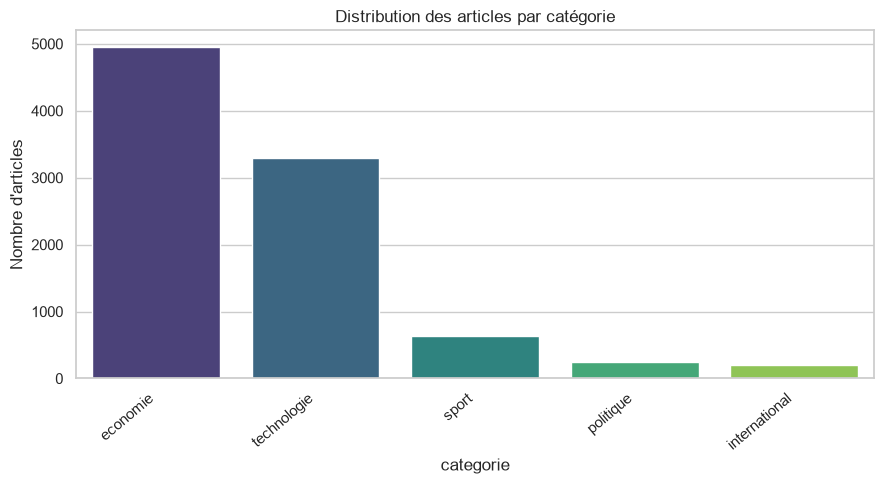

In [11]:
VALID_CATEGORIES = ["economie", "technologie", "sport", "politique", "international"]

df_clean = df[df["categorie"].isin(VALID_CATEGORIES)].copy()

counts = df_clean["categorie"].value_counts()
print(counts)

plt.figure(figsize=(9, 5))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False)
plt.xticks(rotation=40, ha="right")
plt.ylabel("Nombre d'articles")
plt.title("Distribution des articles par catégorie")
plt.tight_layout()
plt.show()


In [12]:
categories_valides = counts[counts >= MIN_SAMPLES_PER_CLASS].index
df = df[df["categorie"].isin(categories_valides)].copy()

print(f"Catégories retenues ({len(categories_valides)}) : {list(categories_valides)}")
print(f"{len(df)} articles restants après filtrage")

if len(categories_valides) < 2:
    raise ValueError(
        "Moins de 2 catégories exploitables : ajoute plus de flux catégorisés "
        "et laisse le temps au crawl d'accumuler des articles avant de relancer ce notebook."
    )


Catégories retenues (5) : ['economie', 'technologie', 'sport', 'politique', 'international']
9313 articles restants après filtrage


## 3. Préparation du texte

In [13]:
df["texte"] = (df["titre"].fillna("") + " " + df["description"].fillna("")).str.strip()
df = df[df["texte"].str.len() > 10].reset_index(drop=True)  # retire les textes quasi vides

print(f"{len(df)} exemples exploitables")
df[["texte", "categorie"]].sample(5, random_state=42)


9307 exemples exploitables


,texte,categorie
1155,Switch to Android easily — and bring your data...,technologie
1790,From natural language to UI tests: A deep dive...,technologie
3003,"Futuro Fofana, il francese verso la Premier? D...",sport
6489,Clash Royale Searches for Its First-Ever Rage ...,economie
592,W dwa miesiące blisko 700 tys. zł. Faktury lek...,politique


## 4. Vectorisation TF-IDF

Ces hyperparamètres (`lowercase`, `ngram_range`, `norm`) doivent rester strictement identiques
à ceux répliqués côté Node (`TfidfService.ts`) — toute modification ici doit être reportée là-bas.


In [14]:
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    lowercase=True,
    ngram_range=(1, 1),
    norm="l2",
    sublinear_tf=False,
    stop_words=None,
)

X = vectorizer.fit_transform(df["texte"]).toarray().astype(np.float32)

classes = sorted(df["categorie"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
y = df["categorie"].map(class_to_idx).values

print(f"Vocabulaire : {len(vectorizer.vocabulary_)} termes (plafonné à {MAX_FEATURES})")
print(f"Classes : {classes}")


Vocabulaire : 2000 termes (plafonné à 2000)
Classes : ['economie', 'international', 'politique', 'sport', 'technologie']


## 5. Entraînement

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000, multi_class="multinomial")
clf.fit(X_train, y_train)

print(f"Train : {X_train.shape[0]} exemples — Test : {X_test.shape[0]} exemples")


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

## 6. Évaluation

In [ ]:
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


## 7. Export ONNX + vectoriseur + manifest

Même format que `train_and_export.py` — le service Node (`MLInferenceService`) lit
`current_manifest.json` et recharge automatiquement le modèle via le hot-reload Redis Pub/Sub
si ce notebook est exécuté pendant que l'API tourne (sinon le prochain démarrage le prendra en compte).


In [1]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

onnx_model = convert_sklearn(
    clf,
    initial_types=[("input", FloatTensorType([None, MAX_FEATURES]))],
    options={id(clf): {"zipmap": False}},
)

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

model_path = OUTPUT_DIR / f"model_{timestamp}.onnx"
with open(model_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

vectorizer_export = {
    "vocabulary": vectorizer.vocabulary_,
    "idf": vectorizer.idf_.tolist(),
    "max_features": MAX_FEATURES,
}
vectorizer_path = OUTPUT_DIR / f"vectorizer_{timestamp}.json"
with open(vectorizer_path, "w", encoding="utf-8") as f:
    json.dump(vectorizer_export, f, ensure_ascii=False)

classes_path = OUTPUT_DIR / f"classes_{timestamp}.json"
with open(classes_path, "w", encoding="utf-8") as f:
    json.dump(classes, f, ensure_ascii=False)

manifest = {
    "model": str(model_path),
    "vectorizer": str(vectorizer_path),
    "classes": str(classes_path),
    "trained_at": timestamp,
    "n_samples": len(df),
}
manifest_path = OUTPUT_DIR / "current_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print(f"Modèle exporté : {model_path}")
print(f"Manifest écrit : {manifest_path}")


NameError: name 'OUTPUT_DIR' is not defined

## 8. Prochaines étapes

- **Amorçage initial** : lance ce notebook une première fois dès que quelques dizaines d'articles
  auront été crawlés sur des flux catégorisés (`is_suggestion: true`, catalogue déjà seedé).
- **Amélioration continue** : les vraies annotations via `POST /ml/feedback` (admin) sont plus
  fiables que les étiquettes héritées des flux — au fil du temps, elles pèseront de plus en plus
  dans le dataset d'entraînement (`MLFeedbackService.exportTrainingData` les priorise déjà).
- **Ré-entraînement automatique en production** : le worker BullMQ (`retrainWorker.ts`) continue
  d'appeler `ml/train_and_export.py` en tâche de fond — si tu modifies la logique ici, reporte les
  changements dans ce script pour que l'automatisation reste cohérente avec ce que tu as validé
  interactivement. Tu peux exporter ce notebook en script avec :
  ```bash
  jupyter nbconvert --to script train_and_export.ipynb --output train_and_export
  ```
  puis adapter les chemins (`OUTPUT_DIR`, arguments CLI `--data`/`--output`) pour qu'il corresponde
  à l'interface attendue par `retrainWorker.ts`.
